<a href="https://colab.research.google.com/github/datacentertugaskuliah-coder/PraktekJST/blob/main/Privacy_Preserving_Data_Preprocessing_for_Bank_Marketing_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATA ACQUISITION AND INITIAL INSPECTION
{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 

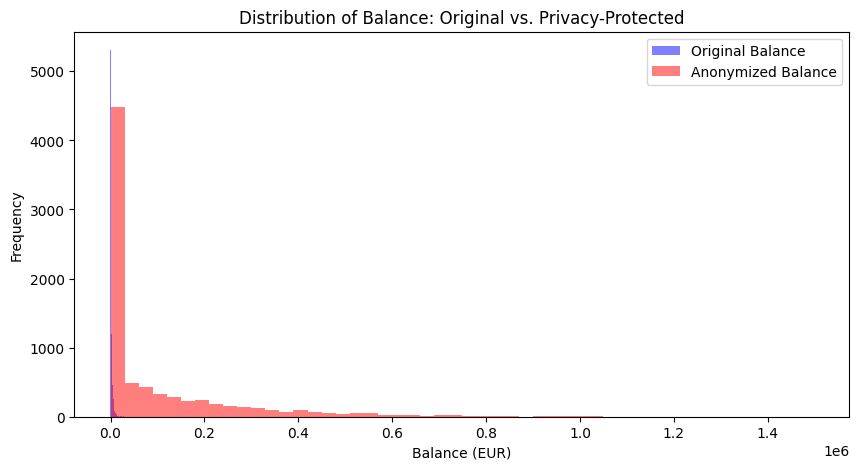


SAMPLE DATA & DOWNLOAD
Contoh 10 data hasil preprocessing privasi:
        marital default housing loan    contact  day_of_week month  duration  \
24060   married      no      no   no  telephone           21   oct        39   
24062    single      no     yes  yes  telephone           21   oct       519   
24064   married      no     yes   no  telephone           21   oct       144   
24072   married      no     yes   no  telephone           22   oct        73   
24077   married      no     yes   no  telephone           23   oct       140   
24086   married      no     yes   no  telephone           25   oct       119   
24122    single      no      no  yes  telephone            4   nov        21   
24127    single      no      no   no  telephone            5   nov       449   
24151  divorced      no     yes   no  telephone           10   nov       175   
24165   married      no     yes   no  telephone           12   nov       119   

       campaign  pdays  previous poutcome    y age_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# =============================================================================
# PROGRAM TITLE: Privacy-Preserving Data Preprocessing for Bank Marketing Dataset
# =============================================================================
# DESKRIPSI SINGKAT:
# Program ini menerapkan teknik anonimisasi data pelanggan Bank Marketing
# (UCI ID 222) dengan tiga lapis perlindungan: pembersihan data,
# generalisasi quasi-identifier untuk mencapai k-anonymity, serta perturbasi
# atribut sensitif 'balance' menggunakan mekanisme differential privacy
# (Laplace). Seluruh proses dijelaskan langkah demi langkah dengan tujuan
# menjaga identitas nasabah tanpa menghilangkan utilitas statistik data.
# Output mengevaluasi k-anonymity hasil generalisasi, membandingkan distribusi
# saldo asli dan anonim, menampilkan sampel data akhir, serta menyediakan
# unduhan data dalam format Excel.
# =============================================================================

# Instalasi library (aman diulang)
!pip install ucimlrepo -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from google.colab import files           # untuk mengunduh file di Colab

# -----------------------------------------------------------------------------
# BAGIAN 1: Mengunduh dan memeriksa dataset dari UCI
# -----------------------------------------------------------------------------
print("="*60)
print("DATA ACQUISITION AND INITIAL INSPECTION")
print("="*60)
bank_marketing = fetch_ucirepo(id=222)  # ID dataset Bank Marketing

# Memisahkan fitur (X) dan target (y) sesuai struktur repositori
X = bank_marketing.data.features
y = bank_marketing.data.targets

# Menampilkan metadata dan informasi variabel untuk pemahaman konteks
print(bank_marketing.metadata)
print("\nVariable Information:")
print(bank_marketing.variables)

# Menggabungkan fitur dan target menjadi satu DataFrame utuh
df = pd.concat([X, y], axis=1)
print(f"\nDimensi data awal (sebelum preprocessing privasi): {df.shape}")
print("Lima baris pertama data awal:")
print(df.head())

# -----------------------------------------------------------------------------
# BAGIAN 2: Lapisan 1 – Pembersihan data (Data Cleansing)
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("LAYER 1: DATA CLEANSING - REMOVING PSEUDO-MISSING VALUES")
print("="*60)
# Nilai 'unknown' pada beberapa kolom merupakan placeholder yang tidak informatif,
# sekaligus berpotensi sebagai noise dalam proses anonimisasi.
# Kami menghilangkan seluruh baris yang mengandung 'unknown' untuk menjaga
# konsistensi dan kualitas data.
df.replace('unknown', pd.NA, inplace=True)
df.dropna(inplace=True)
print(f"Dimensi setelah membersihkan nilai 'unknown': {df.shape}")

# -----------------------------------------------------------------------------
# BAGIAN 3: Lapisan 2 – Generalisasi quasi-identifier (K-Anonymity)
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("LAYER 2: GENERALIZATION OF QUASI-IDENTIFIERS (K-ANONYMITY)")
print("="*60)
# Prinsip: atribut yang bila digabung dapat mengidentifikasi individu (quasi-identifier)
# digeneralisasi ke dalam kelompok yang lebih luas. Hal ini meningkatkan k-anonymity,
# yaitu setiap kombinasi nilai quasi-identifier muncul setidaknya k kali.

# 3a. Generalisasi 'age' (numerik) menjadi kelompok umur 10 tahunan
bins = list(range(0, 101, 10))          # 0, 10, 20, ..., 100
labels = [f'{i}-{i+9}' for i in bins[:-1]]  # '0-9', '10-19', ..., '90-99'
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
df.drop('age', axis=1, inplace=True)
print("-> 'age' digeneralisasi menjadi 'age_group' (interval 10 tahun).")

# 3b. Generalisasi 'education' menjadi jenjang pendidikan yang lebih tinggi
edu_mapping = {
    'basic.4y': 'Basic Education',
    'basic.6y': 'Basic Education',
    'basic.9y': 'Basic Education',
    'high.school': 'High School',
    'illiterate': 'No Formal Education',
    'professional.course': 'Professional Course',
    'university.degree': 'University'
}
df['edu_level'] = df['education'].map(edu_mapping)
df.drop('education', axis=1, inplace=True)
print("-> 'education' digeneralisasi menjadi 'edu_level' (4 kategori).")

# 3c. Generalisasi 'job' menjadi kategori pekerjaan berbasis sektor
job_mapping = {
    'admin.': 'White-Collar',
    'management': 'White-Collar',
    'entrepreneur': 'White-Collar',
    'self-employed': 'White-Collar',
    'blue-collar': 'Blue-Collar',
    'technician': 'Blue-Collar',
    'services': 'Service',
    'housemaid': 'Service',
    'student': 'Student/Unemployed',
    'unemployed': 'Student/Unemployed',
    'retired': 'Retired'
}
df['job_category'] = df['job'].map(job_mapping)
df.drop('job', axis=1, inplace=True)
print("-> 'job' digeneralisasi menjadi 'job_category' (5 kategori).")
print(f"Dimensi setelah generalisasi: {df.shape}")

# -----------------------------------------------------------------------------
# BAGIAN 4: Lapisan 3 – Perturbasi atribut sensitif (Differential Privacy)
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("LAYER 3: PERTURBATION OF SENSITIVE ATTRIBUTE (DIFFERENTIAL PRIVACY)")
print("="*60)
# Atribut 'balance' (saldo rata-rata tahunan) sangat sensitif.
# Kami menerapkan mekanisme Laplace untuk memberikan jaminan (ε,0)-differential privacy.
# Parameter:
# - Sensitivity : 100.000 (selisih maksimum saldo antar nasabah, asumsi)
# - ε (epsilon) : 0,5  (anggaran privasi, makin kecil makin kuat perlindungan)
# Noise dihasilkan dari distribusi Laplace dengan skala = sensitivity/ε,
# lalu ditambahkan ke nilai asli. Saldo hasil anonimisasi dijepit minimum 0.

sensitivity = 100_000.0
epsilon = 0.5
scale = sensitivity / epsilon

# Simpan saldo asli untuk evaluasi utilitas (tanpa mencemari data final)
original_balance = df['balance'].copy()

# Reproduktibilitas noise
np.random.seed(42)
laplace_noise = np.random.laplace(loc=0, scale=scale, size=len(df))

# Penambahan noise dan kliping nilai negatif
df['balance_anonymized'] = np.maximum(0, df['balance'] + laplace_noise.astype(int))

# Hapus kolom saldo asli agar tidak terekspos
df.drop('balance', axis=1, inplace=True)
print(f"-> 'balance' telah dianonimkan dengan noise Laplace (ε = {epsilon}).")

# -----------------------------------------------------------------------------
# BAGIAN 5: Evaluasi hasil anonimisasi
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("ANONYMIZATION EVALUATION OUTPUT")
print("="*60)

# 5a. Pengukuran k-anonymity
# Kombinasi quasi-identifier setelah generalisasi
quasi_identifiers = ['age_group', 'job_category', 'marital', 'edu_level']

# Revisi: tambahkan observed=False untuk menghindari FutureWarning dan konsisten
# dengan perilaku default saat ini
group_sizes = df.groupby(quasi_identifiers, observed=False).size()
k_min = group_sizes.min()
k_avg = group_sizes.mean()

print(f"Evaluasi k-anonymity pada {quasi_identifiers}:")
print(f"  - Nilai k minimum (k_min)           : {k_min}")
print(f"  - Rata-rata ukuran grup             : {k_avg:.2f}")
print("  Interpretasi: Semakin tinggi k_min, semakin sulit membedakan individu dalam dataset.\n")

# 5b. Perbandingan statistik deskriptif saldo (utilitas data)
print("Perbandingan Statistik Saldo (Original vs Anonymized):")
print(f"{'Statistik':<20} {'Asli':>10} {'Anonim':>10}")
print("-" * 40)
stats_orig = original_balance.describe()
stats_anon = df['balance_anonymized'].describe()
for stat_name in ['min', '25%', '50%', '75%', 'max', 'mean', 'std']:
    print(f"{stat_name:<20} {stats_orig[stat_name]:>10.2f} {stats_anon[stat_name]:>10.2f}")

# 5c. Visualisasi distribusi (opsional namun informatif)
plt.figure(figsize=(10,5))
plt.hist(original_balance, bins=50, alpha=0.5, label='Original Balance', color='blue')
plt.hist(df['balance_anonymized'], bins=50, alpha=0.5, label='Anonymized Balance', color='red')
plt.title('Distribution of Balance: Original vs. Privacy-Protected')
plt.xlabel('Balance (EUR)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# -----------------------------------------------------------------------------
# BAGIAN 6: Menampilkan contoh data dan menyediakan unduhan Excel
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("SAMPLE DATA & DOWNLOAD")
print("="*60)
# Menampilkan 10 baris pertama data hasil anonimisasi
print("Contoh 10 data hasil preprocessing privasi:")
print(df.head(10))

# Simpan DataFrame ke file Excel dan unduh
output_file = "bank_marketing_anonymized.xlsx"
df.to_excel(output_file, index=False)
print(f"\nData berhasil disimpan ke '{output_file}'.")
print("Menginisiasi unduhan...")
files.download(output_file)